# Flight Tracks over Land Cover

## Overview

This notebook generates publication-quality maps of the SAMBBA research flight trajectories overlaid on a MODIS land cover classification. The figures provide the geographical context of the aircraft observations and illustrate the spatial coverage of the research flights used throughout the analysis.

## Workflow

1. Load the processed FAAM core datasets for the selected research flights.
2. Load the MODIS land cover product and ancillary geographical datasets.
3. Create a reusable land cover basemap.
4. Overlay individual or multiple research flight trajectories.
5. Generate publication-quality figures for the manuscript.

## Inputs

- Processed FAAM core datasets containing the aircraft navigation data.
- MODIS MCD12C1 Land Cover Type product.
- Ancillary shapefiles containing roads and populated places.

## Outputs

- Publication-quality maps showing individual research flight trajectories over the land cover classification.
- A combined map displaying the trajectories of all selected SAMBBA research flights.

## Requirements

This notebook assumes that the SAMBBA datasets have already been downloaded and organized following the repository directory structure. The required MODIS land cover product and ancillary shapefiles must also be available locally.

In [34]:
# Import the libraries required for data processing, statistical analysis and visualization.
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as patheffects

In [57]:
# Define the location of the SAMBBA flight archive and identify the flights to be included in the analysis.
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs =  [
    "b734-sep-18", "b737-sep-20", "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", "b749-oct-03", 
]


In [58]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

In [80]:
# Extract the flight identifier (e.g., "b734") from a file path.
# The flight identifier is used to associate the different instrument
# datasets belonging to the same research flight.
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None


# Identify the available research flights represented in the FAAM core files.
flights_nc = {extract_flight_number(f) for f in filtered_files}

# Retain only files associated with the identified research flights.
filtered_nc = [
    f for f in filtered_files
    if extract_flight_number(f) in flights_nc
]

print(f"Filtered NC files: {len(filtered_nc)}")

filtered_nc[0]

# Extract the flight date from the filename. This information is later
# used to synchronize datasets and to identify individual research flights.
match = re.search(r'(\d{8})', filtered_nc[0])

# Return the flight date in YYYYMMDD format.
flight_date = match.group(1) if match else None

print(flight_date)  # Example: 20120914

Filtered NC files: 10
20120918


In [74]:
def var_plot_landcover():
    # Open the dataset
    # Load the satellite dataset (e.g., MODIS data) using xarray. The dataset is in HDF format, 
    # so the "netcdf4" engine is specified to handle the file correctly.
    ds = xr.open_dataset('./MCD12C1.A2013001.061.2022165063153.hdf', engine="netcdf4")
    #MCD12C1.A2012001.061.2022162172724.hdf
    
    # Sort the Y-axis in descending order
    ds = ds.sortby("YDim:MOD12C1", ascending=False)
    
    # Generate latitude and longitude arrays
    # Create a latitude array with values ranging from -90 to 90, evenly spaced for 3600 points.
    # This corresponds to the number of points along the YDim:MOD12C1 dimension of the dataset.
    latitude = np.linspace(-90, 90, 3600)  # For YDim:MOD12C1
    
    # Create a longitude array with values ranging from -180 to 180, evenly spaced for 7200 points.
    # This corresponds to the number of points along the XDim:MOD12C1 dimension of the dataset.
    longitude = np.linspace(-180, 180, 7200)  # For XDim:MOD12C1
    
    # Assign latitude and longitude as coordinates with explicit dimensions
    # Use the `assign_coords` method to add the generated latitude and longitude arrays
    # as coordinates to the dataset. The "latitude" array is tied to the YDim:MOD12C1 dimension,
    # and the "longitude" array is tied to the XDim:MOD12C1 dimension.
    ds = ds.assign_coords({
        "latitude": ("YDim:MOD12C1", latitude), 
        "longitude": ("XDim:MOD12C1", longitude)
    })
    
    # Replace the existing dimensions with the newly assigned coordinates
    # The `swap_dims` method is used to replace the YDim:MOD12C1 dimension with "latitude"
    # and the XDim:MOD12C1 dimension with "longitude". This makes the dataset directly indexable
    # using latitude and longitude values instead of the original dimension labels.
    ds = ds.swap_dims({"YDim:MOD12C1": "latitude", "XDim:MOD12C1": "longitude"})
    
    
    # Define the bounding box coordinates for a region of interest
    # These coordinates specify the minimum and maximum longitude (minlon, maxlon)
    # and latitude (minlat, maxlat) for the region you want to extract from the dataset.
    
    # Box 1: The bounding box covers a specific region in the Amazon area
    #minlon, maxlon, minlat, maxlat = -72, -48, -11, -3  # Example box 1
    minlon, maxlon, minlat, maxlat = -66.5, -45.5, -12, -6  # Example box 2
    # ax3.set_extent([-66.5, -45.5, -12, -6], crs=ccrs.PlateCarree())
    
    ds_subset = ds.sel(
        latitude=slice(minlat, maxlat),  # Latitude slicing (descending order)
        longitude=slice(minlon, maxlon)  # Longitude slicing (ascending order)
    )
    
    # Define the land cover classes and their corresponding descriptive names
    # Each key in the dictionary represents a class number, and its value is the name of the land cover type.
    land_cover_classes = {
        0: "Water",
        1: "Evergreen Needleleaf Forest",
        2: "Forests",
        3: "Deciduous Needleleaf Forest",
        4: "Deciduous Broadleaf Forest",
        5: "Mixed Forests",
        6: "Closed Shrubland",
        7: "Open Shrublands",
        8: "Woody Savannas",
        9: "Savannas",
        10: "Grasslands",
        11: "Permanent Wetlands",
        12: "Croplands",
        13: "Urban and Built-Up",
        14: "Cropland/Natural Vegetation Mosaic",
        15: "Snow and Ice",
        16: "Barren or Sparsely Vegetated",
    }
    
    # Define a list of custom colors corresponding to the land cover classes
    # These colors will be used in the plot to represent each class visually.
    custom_colors = [
        "blue",         # 0: Water
        "darkgreen",    # 1: Evergreen Needleleaf Forest
        "limegreen",    # 2: Evergreen Broadleaf Forest
        "yellowgreen",  # 3: Deciduous Needleleaf Forest
        "olivedrab",    # 4: Deciduous Broadleaf Forest
        "olive",        # 5: Mixed Forests
        "brown",        # 6: Closed Shrubland
        "peru",         # 7: Open Shrublands
        "tan",          # 8: Woody Savannas
        "khaki",        # 9: Savannas
        "gold",         # 10: Grasslands
        "aqua",         # 11: Permanent Wetlands
        "orange",       # 12: Croplands
        "red",          # 13: Urban and Built-Up
        "teal",         # 14: Cropland/Natural Vegetation Mosaic
        "white",        # 15: Snow and Ice
        "gray"          # 16: Barren or Sparsely Vegetated
    ]
    
    # Create a colormap using the custom colors
    # The colormap maps the land cover classes to the corresponding colors for visualization.
    custom_cmap = ListedColormap(custom_colors)
    
    # Define a normalization that maps class numbers to colors in the colormap
    # BoundaryNorm ensures the colors align correctly with the class boundaries.
    num_classes = len(land_cover_classes)  # Total number of land cover classes
    cmap = custom_cmap
    norm = mcolors.BoundaryNorm(
        boundaries=np.arange(-0.5, len(custom_colors) + 0.5, 1),  # Boundaries between classes
        ncolors=len(custom_colors)  # Total number of colors
    )
    
    # Define the classes that appear on the map (optional)
    # This is useful if not all classes are present in the region being plotted.
    #active_classes = [0, 2, 4, 5, 8, 9, 10, 11, 12, 13]  # Example subset of active classes
    active_classes = [0, 2, 9, 10, 12]  # Example subset of active classes
    
    # Filter the land cover classes to include only the active classes
    # This creates a smaller dictionary with just the classes that are present.
    filtered_land_cover_classes = {k: land_cover_classes[k] for k in active_classes}
    #print(filtered_land_cover_classes)
    
    # Filter the colors to match the active classes
    # This ensures that the colormap contains only the colors for the active classes.
    filtered_colors = [custom_colors[k] for k in active_classes]
    #print(filtered_colors)
    
    # Create a new colormap using the filtered colors
    # The new colormap will include only the colors corresponding to the active classes.
    filtered_cmap = ListedColormap(filtered_colors)
    #print(filtered_cmap)
    
    # Update the normalization to match the filtered classes
    # This ensures that the color mapping aligns with the filtered colormap.
    norm2 = mcolors.BoundaryNorm(
        boundaries=np.arange(0, len(filtered_colors), 1),  # Adjust boundaries to the filtered classes
        ncolors=len(filtered_colors)  # Total number of filtered colors
    )

    # Define the file paths for shapefiles that contain geographical data
    cities_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_populated_places.shp"  # Cities shapefile
    roads_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_roads.shp"
    #"../GOES-Fire-Inventory/
    # Read the shapefiles for cities, roads, and urban areas into GeoDataFrames
    cities = gpd.read_file(cities_shapefile)
    roads = gpd.read_file(roads_shapefile)
    
    return minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes

In [81]:

# Load the geographical layers, land cover information and plotting
# parameters required to generate the flight maps.
minlon, maxlon, minlat, maxlat, roads, cities, ds_subset, cmap, norm, \
filtered_colors, filtered_land_cover_classes, active_classes = var_plot_landcover()

In [82]:
def plot_flight_track_over_landcover(
    flight_number,
    flight_date,
    ds_psap,
    save_path=None,
    step=35000,
):
    """
    Plot the flight trajectory over a MODIS land cover map together with
    the main roads and populated places within the study region.

    Parameters
    ----------
    flight_number : str or int
    flight_date : str
    ds_psap : xarray.Dataset
        Dataset containing the aircraft latitude (LAT_GIN) and longitude
        (LON_GIN) coordinates.
    save_path : str or None
        Output path for the figure. If None, the figure is saved using
        a default filename.
    step : int
        Subsampling interval used to draw direction arrows along the
        flight trajectory.
    """

    # Load the geographical datasets and plotting parameters required
    # to build the land cover map.
    minlon, maxlon, minlat, maxlat, roads, cities, ds_subset, cmap, norm, \
        filtered_colors, filtered_land_cover_classes, active_classes = var_plot_landcover()

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_axes([0.07, 0.12, 0.72, 0.78], projection=ccrs.PlateCarree())
    ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())

    # Retrieve the aircraft position and discard invalid geographic
    # coordinates before plotting the flight trajectory.
    lat_valid = ds_psap["LAT_GIN"]
    lon_valid = ds_psap["LON_GIN"]

    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True)
    lon_filtered = lon_valid.where(valid_mask, drop=True)

    lat = lat_filtered.values
    lon = lon_filtered.values

    # Remove any remaining missing coordinates.
    valid_points = (~np.isnan(lat)) & (~np.isnan(lon))
    lat = lat[valid_points]
    lon = lon[valid_points]

    # Plot the MODIS land cover classification as the map background.
    ds_subset["Majority_Land_Cover_Type_1"].plot(
        ax=ax,
        x="longitude",
        y="latitude",
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
        zorder=0,
    )

    # Overlay the main roads and populated places to provide additional
    # geographical context for the flight trajectory.
    roads.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        color="gray",
        linestyle="--",
        linewidth=1.0,
        label="Main roads"
    )

    ax.scatter(
        cities.geometry.x,
        cities.geometry.y,
        color="black",
        s=15,
        transform=ccrs.PlateCarree(),
        label="Cities"
    )

    # Plot the aircraft flight trajectory.
    ax.plot(
        lon,
        lat,
        transform=ccrs.PlateCarree(),
        color="purple",
        linewidth=1.0,
        label="Flight track"
    )

    # Add arrows indicating the direction of the aircraft along the
    # flight path using regularly subsampled positions.
    if step is not None and step > 1 and len(lon) > step:

        lon_sub = lon[::step]
        lat_sub = lat[::step]

        dx = np.diff(lon_sub)
        dy = np.diff(lat_sub)

        # Compute the midpoint of each trajectory segment to position
        # the direction arrows.
        lon_mid = lon_sub[:-1] + dx / 2
        lat_mid = lat_sub[:-1] + dy / 2

        ax.quiver(
            lon_mid,
            lat_mid,
            dx,
            dy,
            transform=ccrs.PlateCarree(),
            scale_units="xy",
            angles="xy",
            scale=2.5,
            color="purple",
            width=0.002
        )

    # Configure the map grid and geographic labels.
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    gl.bottom_labels = gl.left_labels = True
    gl.xlines = False
    gl.ylines = False
    gl.xlocator = mticker.MultipleLocator(5)
    gl.ylocator = mticker.MultipleLocator(1)

    # Build a combined legend including both the land cover classes
    # and the geographical features displayed on the map.
    landcover_handles = [
        plt.Line2D(
            [0], [0],
            color=filtered_colors[i],
            lw=4,
            label=f"{filtered_land_cover_classes[cls]}"
        )
        for i, cls in enumerate(active_classes)
    ]

    additional_handles = [
        plt.Line2D([0], [0], color="gray", lw=1.0, linestyle="--", label="Main roads"),
        plt.Line2D([0], [0], color="black", marker="o", markersize=5, linestyle="", label="Cities"),
        plt.Line2D([0], [0], color="purple", lw=2.0, linestyle="-", label="Flight Track"),
    ]

    handles = landcover_handles + additional_handles

    ax.legend(
        handles=handles,
        loc="lower left",
        bbox_to_anchor=(1.02, -0.05),
        title="Legend",
        fontsize=8,
        title_fontsize=8,
        frameon=False
    )

    ax.set_title(f"Flight {flight_number} - Flight Track over Land cover")

    # Save the figure using either the user-defined filename or the
    # default output name.
    if save_path is None:
        save_path = f"./flight_track_landcover_{flight_number}.png"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Figure saved as {save_path}")

    return fig, ax

In [83]:
def make_landcover_basemap(figsize=(12, 8)):
    """
    Create a land cover basemap that can be reused to display one or
    multiple SAMBBA flight trajectories.

    Parameters
    ----------
    figsize : tuple, optional
        Figure size in inches.

    Returns
    -------
    matplotlib.figure.Figure
        Figure object.

    matplotlib.axes.Axes
        Cartopy map axis.

    list
        Legend handles containing the land cover classes and the
        flight-track symbol.
    """

    # Load the geographical datasets and plotting parameters required
    # to construct the land cover basemap.
    minlon, maxlon, minlat, maxlat, roads, cities, ds_subset, cmap, norm, \
        filtered_colors, filtered_land_cover_classes, active_classes = var_plot_landcover()

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0.07, 0.12, 0.72, 0.78], projection=ccrs.PlateCarree())
    ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())

    # Plot the MODIS land cover classification as the map background.
    ds_subset["Majority_Land_Cover_Type_1"].plot(
        ax=ax,
        x="longitude",
        y="latitude",
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
        zorder=0,
    )

    # Roads and populated places may be added if additional geographic
    # context is required.
    # roads.plot(...)
    # ax.scatter(...)

    # Configure the map grid and geographic labels.
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    gl.bottom_labels = gl.left_labels = True
    gl.xlines = False
    gl.ylines = False
    gl.xlocator = mticker.MultipleLocator(5)
    gl.ylocator = mticker.MultipleLocator(1)

    # Increase the label size for improved readability.
    gl.xlabel_style = {"size": 16}
    gl.ylabel_style = {"size": 16}

    # Create legend entries for the land cover classes displayed on
    # the map.
    landcover_handles = [
        plt.Line2D(
            [0], [0],
            color=filtered_colors[i],
            lw=4,
            label=f"{filtered_land_cover_classes[cls]}"
        )
        for i, cls in enumerate(active_classes)
    ]

    # Initialize the legend with the land cover classes and a generic
    # flight-track symbol. Additional flight-specific entries can be
    # appended later.
    base_handles = landcover_handles + [
        plt.Line2D(
            [0], [0],
            color="purple",
            lw=2.0,
            linestyle="-",
            label="Flight Track"
        ),
    ]

    return fig, ax, base_handles

In [84]:
def add_flight_track(
    ax,
    ds_psap,
    flight_number,
    color="purple",
    linewidth=2.5,
    label_offset=-0.05,
):
    """
    Add a single research flight trajectory to an existing land cover map.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Map axis where the flight track will be plotted.
    ds_psap : xarray.Dataset
        Dataset containing the aircraft latitude (LAT_GIN) and longitude
        (LON_GIN) coordinates.
    flight_number : str
        Flight identifier displayed along the trajectory.
    color : str, optional
        Color used to draw the flight track and its label.
    linewidth : float, optional
        Width of the flight track.
    label_offset : float, optional
        Latitude offset applied to the flight label to improve readability.
    """

    # Retrieve the aircraft position and discard invalid geographic
    # coordinates before plotting the flight trajectory.
    lat_valid = ds_psap["LAT_GIN"]
    lon_valid = ds_psap["LON_GIN"]

    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True).values
    lon_filtered = lon_valid.where(valid_mask, drop=True).values

    # Remove any remaining missing coordinates.
    ok = (~np.isnan(lat_filtered)) & (~np.isnan(lon_filtered))
    lat = lat_filtered[ok]
    lon = lon_filtered[ok]

    # Skip flights without sufficient valid observations to define a
    # continuous trajectory.
    if len(lon) < 2:
        return

    # Plot the aircraft trajectory over the existing land cover map.
    ax.plot(
        lon,
        lat,
        transform=ccrs.PlateCarree(),
        color=color,
        linewidth=linewidth,
        zorder=3,
    )

    # Annotate the flight using its identifier positioned near the
    # midpoint of the trajectory.
    mid_idx = len(lon) // 2
    ax.text(
        lon[mid_idx],
        lat[mid_idx] + label_offset,
        flight_number,
        transform=ccrs.PlateCarree(),
        fontsize=9,
        fontweight="bold",
        color=color,
        ha="center",
        va="bottom",
        zorder=4,
        path_effects=[
            patheffects.withStroke(linewidth=2, foreground="white")
        ],
    )

Figure saved as ./all_flights_tracks_landcover_paper.png


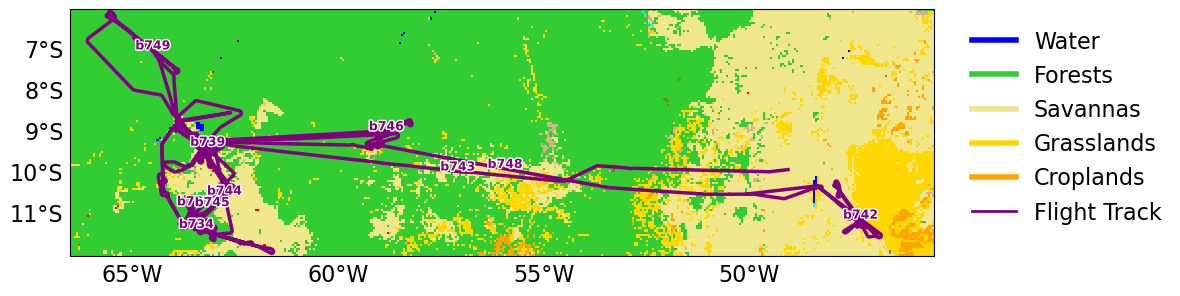

In [85]:
# Create the common land cover basemap that will serve as the background
# for all SAMBBA research flight trajectories.
fig, ax, base_handles = make_landcover_basemap(figsize=(12, 8))

# Overlay the trajectory of each research flight on the common basemap.
for nc_file in filtered_nc:

    ds_core = xr.open_dataset(nc_file)

    # Extract the flight identifier from the filename to annotate the map.
    match = re.search(r"b\d{3}", nc_file)
    flight_number = match.group(0) if match else "Unknown"

    add_flight_track(
        ax=ax,
        ds_psap=ds_core,
        flight_number=flight_number,
        color="purple",
        linewidth=2.5,
    )

# Add the legend describing the land cover classes and the flight-track
# symbol used throughout the figure.
ax.legend(
    handles=base_handles,
    loc="lower left",
    bbox_to_anchor=(1.02, 0.05),
    fontsize=16,
    frameon=False,
)

# Save the publication-quality map showing the trajectories of all
# selected SAMBBA research flights.
plt.savefig(
    "./all_flights_tracks_landcover_paper.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved as ./all_flights_tracks_landcover_paper.png")